# Vấn đề thỏa mãn ràng buộc: Tô màu đồ thị

## Tạo dữ liệu

Chúng ta có thể tạo một đồ thị phẳng với $n$ đỉnh bằng cách đặt ngẫu nhiên $n$ điểm trong không gian Euclid 2 chiều và sau đó thực hiện một [phân hoạch Delaunay](https://en.wikipedia.org/wiki/Delaunay_triangulation).

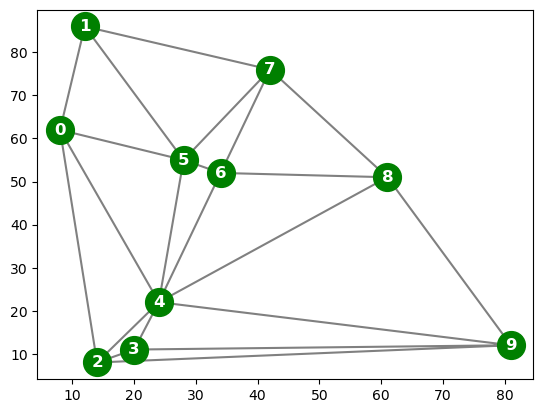

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay

np.random.seed(1111)

# create points and sort them by 
n = 10
points = np.random.randint(100, size=(n, 2))
o = np.argsort(points[:,0])
points = points[o,:]


# triangulate
tri = Delaunay(points)


# plot
plt.triplot(points[:,0], points[:,1], tri.simplices, color = "gray")
plt.plot(points[:,0], points[:,1], 'o', color = "green", markersize = 20)

for i in range(len(points)):
       plt.annotate(i, points[i,:], 
        color='white', fontsize="large", weight='heavy',
        horizontalalignment='center', verticalalignment='center')

plt.show()

- Trong đoạn code trên ta có:
  + Tạo ngẫu nhiên n điểm 2D, cố định seed để tái lập.
  + Dùng Delaunay triangulation để sinh các cạnh, tạo một đồ thị phẳng từ các điểm.
  + Vẽ đồ thị: các cạnh là màu xám & các đỉnh là màu xanh lá, gán nhãn số cho từng đỉnh.

Có thể chuyển kết quả tam giác hóa thành một danh sách, trong đó mỗi phần tử là mảng chỉ mục các đỉnh láng giềng của từng điểm (xem trang hướng dẫn của [scipy.spatial.Delaunay](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.Delaunay.html)).

In [2]:
(indptr, indices) = tri.vertex_neighbor_vertices

neighbors = []

for k in range(len(indptr)-1):
    neighbors.append(np.sort(indices[indptr[k]:indptr[k+1]]))
    
neighbors

[array([1, 2, 4, 5], dtype=int32),
 array([0, 5, 7], dtype=int32),
 array([0, 3, 4, 9], dtype=int32),
 array([2, 4, 9], dtype=int32),
 array([0, 2, 3, 5, 6, 8, 9], dtype=int32),
 array([0, 1, 4, 6, 7], dtype=int32),
 array([4, 5, 7, 8], dtype=int32),
 array([1, 5, 6, 8], dtype=int32),
 array([4, 6, 7, 9], dtype=int32),
 array([2, 3, 4, 8], dtype=int32)]

- Dùng cấu trúc `tri.vertex_neighbor_vertices` của Delaunay để suy ra danh sách kề của đồ thị. Mỗi điểm sẽ có một mảng chỉ mục các đỉnh láng giềng (những điểm nối cạnh với nó trong tam giác).
- Mục đích nhằm tạo đầu vào cấu trúc cho bài toán CSP tô màu đồ thị:
  + Dễ dàng xây dựng tập ràng buộc giữa các cặp đỉnh kề nhau.
  + Chuyển từ biểu diễn hình học (tam giác hóa) sang biểu diễn đồ thị phục vụ các thuật toán tìm kiếm/heuristic.

Hàng đầu tiên là các chỉ mục của những điểm láng giềng. Cụ thể sẽ là:
- Đỉnh `0` gồm các đỉnh kề như: `{1, 2, 4, 5}`.
- Đỉnh `1` gồm các đỉnh kề như: `{0, 5, 7}`.
- Đỉnh `2` gồm các đỉnh kề như: `{0, 3, 4, 9}`.
- Đỉnh `3` gồm các đỉnh kề như: `{2, 4, 9}`.
- Đỉnh `4` gồm các đỉnh kề như: `{0, 2, 3, 5, 6, 8, 9}`.
- Đỉnh `5` gồm các đỉnh kề như: `{0, 1, 4, 6, 7}`.
- Đỉnh `6` gồm các đỉnh kề như: `{4, 5, 7, 8}`.
- Đỉnh `7` gồm các đỉnh kề như: `{1, 5, 6, 8}`.
- Đỉnh `8` gồm các đỉnh kề như: `{4, 6, 7, 9}`.
- Đỉnh `9` gồm các đỉnh kề như: `{2, 3, 4, 8}`.

## Định nghĩa CSP

Bài toán được mô tả bằng một dictionary gồm danh sách biến, một dictionary miền giá trị cho từng biến và tập các ràng buộc nhị phân kiểu “khác nhau” (các cặp biến không được nhận cùng một giá trị).  

In [3]:
variables = [str(var) for var in range(n)]

domain = ['red', 'blue', 'green', 'orange']
#domain = ['red', 'blue', 'green']
domains = {}
for v in variables: 
    domains[v] = domain

# create binary constraints
constraints = {}
for i in range(len(neighbors)):
    for j in neighbors[i]:
        if(i<j): constraints[tuple([str(i), str(j)])] = True
constraints = constraints.keys()

csp = {'variables': variables, 'domains': domains, 'constraints': constraints, }
csp

{'variables': ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'],
 'domains': {'0': ['red', 'blue', 'green', 'orange'],
  '1': ['red', 'blue', 'green', 'orange'],
  '2': ['red', 'blue', 'green', 'orange'],
  '3': ['red', 'blue', 'green', 'orange'],
  '4': ['red', 'blue', 'green', 'orange'],
  '5': ['red', 'blue', 'green', 'orange'],
  '6': ['red', 'blue', 'green', 'orange'],
  '7': ['red', 'blue', 'green', 'orange'],
  '8': ['red', 'blue', 'green', 'orange'],
  '9': ['red', 'blue', 'green', 'orange']},
 'constraints': dict_keys([('0', '1'), ('0', '2'), ('0', '4'), ('0', '5'), ('1', '5'), ('1', '7'), ('2', '3'), ('2', '4'), ('2', '9'), ('3', '4'), ('3', '9'), ('4', '5'), ('4', '6'), ('4', '8'), ('4', '9'), ('5', '6'), ('5', '7'), ('6', '7'), ('6', '8'), ('7', '8'), ('8', '9')])}

- Mã hóa bài toán tô màu đồ thị thành một CSP:
  + Biến `variables`: mỗi đỉnh là một biến (đặt tên chuỗi 0...n-1).
  + Miền `domains`: tập màu khả dụng (4 màu `Red`, `Blue`, `Green`, `Orange`).
  + Ràng buộc `constraints`: với mỗi cặp đỉnh kề (từ `neighbors`), thêm ràng buộc “khác nhau” (không được trùng màu).
- Mục tiêu nhằm tạo cấu trúc `csp` chuẩn (variables, domains, constraints) để:
  + Dùng trực tiếp cho các thuật toán tìm kiếm/quay lui cho bài toán.
  + Dễ thay đổi số màu (3/4) và tự động sinh ràng buộc từ danh sách kề đã trích từ Delaunay.

## Kiểm tra tính đầy đủ và tính nhất quán

`assignment` là một dictionary. Các biến đã được gán có một mục với tên biến làm khóa. `{}` do đó là phép gán rỗng.

In [4]:
def complete(assignment, csp):
    return(all([v in assignment.keys() for v in csp['variables']])) 

print("complete({}, csp) =", complete({}, csp))

print("complete({...complete list...}, csp) =", 
      complete({'0': 'red', '1': 'red', '2': 'red', '3': 'red', '4': 'red', 
          '5': 'red', '6': 'red', '7': 'red', '8': 'red', '9': 'red'}, csp))

complete({}, csp) = False
complete({...complete list...}, csp) = True


- Trích danh sách kề từ đối tượng Delaunay bằng `tri.vertex_neighbor_vertices`. Với mỗi đỉnh k, lấy đoạn `indices[indptr[k]:indptr[k+1]]`, sắp xếp (`np.sort`) rồi đưa vào `neighbors`.
- Mục tiêu là để thu được cấu trúc kề chuẩn (mỗi đỉnh -> mảng chỉ mục láng giềng) để:
  + Xây dựng tập ràng buộc “khác nhau” giữa các cặp đỉnh kề trong CSP.
  + Chuyển từ biểu diễn tam giác hóa sang biểu diễn đồ thị phục vụ các thuật toán tìm kiếm/heuristic.

In [ ]:
def consistent(assignment, csp):
    for constr in csp['constraints']:
        if(constr[0] in assignment.keys() and constr[1] in assignment.keys()):
            if assignment[constr[0]] == assignment[constr[1]]: return(False)
        
    return(True)
        
print("consistent({}, csp) =", consistent({}, csp))
print("consistent({'0': 'red', '1': 'red', '2': 'blue'}, csp) =", 
      consistent({'0': 'red', '1': 'red', '2': 'blue'}, csp))

consistent({}, csp) = True
consistent({'0': 'red', '1': 'red', '2': 'blue'}, csp) = False


- Hàm `consistent(assignment, csp)` kiểm tra tính nhất quán cục bộ của phép gán hiện tại. Duyệt mọi ràng buộc `(u, v)`; nếu cả `u` và `v` đã được gán và giá trị trùng nhau thì trả về `False`, ngược lại tiếp tục.
- Mục tiêu: 
  + Dùng để phát hiện sớm mâu thuẫn trong quá trình quay lui: chỉ tiếp tục mở rộng những phép gán còn hợp lệ.
  + Ví dụ: `consistent({}, csp) = True` (chưa có mâu thuẫn), `consistent({'0': 'red', '1': 'red', '2': 'blue'}, csp) = False` do `0` và `1` là đỉnh kề và bị trùng màu.

## Cài đặt tìm kiếm quay lui đơn giản

In [6]:
# TODO: implement variable ordering. Choose variable with the minimum-remaining-values (MRV)
def select_unassigned_var(assignment, csp):
    if(complete(assignment, csp)): return(None)
    
    return(csp['variables'][np.where([not v in assignment.keys() for v in csp['variables']])[0][0]])

print("select_unassigned_var({'0': 'red', '1': 'blue'}, csp) =", 
     select_unassigned_var({'0': 'red', '1': 'blue'}, csp))

select_unassigned_var({'0': 'red', '1': 'blue'}, csp) = 2


- Xây “bộ chọn biến kế tiếp” `select_unassigned_var(assignment, csp)`. Hiện tại hàm trả về biến chưa gán đầu tiên (baseline). Trước khi chọn, nếu `assignment` đã đầy đủ thì trả về `None`.
- Mục tiêu:
  + Xác định biến sẽ gán tiếp theo.
  + Dễ dàng nâng cấp sang heuristic chọn biến tốt hơn để giảm nhánh tìm kiếm.

In [7]:
# I use a global variable to turn on verbose mode in the recursion
#VERBOSE = True
VERBOSE = False
COUNT = 0

# returns None for failure
def backtrack_search(csp):
    global COUNT
    COUNT = 0
    
    assignment = backtrack({}, csp)
    
    print(f"Checked nodes: {COUNT}")
    
    return assignment

def backtrack(assignment, csp):
    global VERBOSE, COUNT
    
    COUNT += 1
    
    if complete(assignment, csp): 
        return assignment
    
    var = select_unassigned_var(assignment, csp)
    
    # TODO: implement value ordering. Use the least-constraining-vaue heuristic. 
    # for val in order_domain(assignment, var, csp)
    for val in csp['domains'][var]:
        assignment[var] = val
        
        if VERBOSE: print(f"Checking: {assignment}")
        
        if consistent(assignment, csp):
            
            #TODO: add inference for early failing (forward checking, )
            # if inference_fails(assignment, csp): return(None)
            result = backtrack(assignment, csp)
            if not result is None:
                    return(result)
                
        del assignment[var]
        
    if VERBOSE: print(f"Backtracking")
    return(None) 

- Cài đặt thuật toán backtracking search hoàn chỉnh với hai hàm chính:
  + `backtrack_search(csp)`: hàm wrapper khởi tạo biến đếm `COUNT` và gọi `backtrack({}, csp)`.
  + `backtrack(assignment, csp)`: hàm đệ quy thực hiện tìm kiếm quay lui. Với mỗi biến chưa gán, thử từng giá trị trong miền, kiểm tra tính nhất quán, và đệ quy tiếp nếu hợp lệ.
- Mục tiêu:
  + Tạo framework cơ bản cho backtracking search với khả năng đo đếm số nút đã kiểm tra (`COUNT`).
  + Thứ tự chọn giá trị (least-constraining-value), forward checking để phát hiện sớm thất bại.
  + Cung cấp chế độ verbose để debug quá trình tìm kiếm.

## Chạy tìm kiếm quay lui trên bài toán ngẫu nhiên

In [17]:
%timeit -n1 -r1 display(backtrack_search(csp))

Checked nodes: 11


{'0': 'red',
 '1': 'blue',
 '2': 'blue',
 '3': 'red',
 '4': 'green',
 '5': 'orange',
 '6': 'red',
 '7': 'green',
 '8': 'blue',
 '9': 'orange'}

20.6 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


- Thực thi thuật toán backtracking search trên bài toán CSP đã tạo bằng cách gọi `backtrack_search(csp)` và đo thời gian chạy bằng `%timeit`.
- Mục tiêu:
  + Kiểm tra thuật toán tìm được nghiệm hợp lệ cho đồ thị 10 đỉnh với 4 màu.
  + Kiểm tra 11 nút và chạy trong ~20.6ms, cho thấy backtracking search hiệu quả trên instance này.
  + Chuẩn bị cho việc so sánh hiệu năng với các thuật toán nâng cao.

Vẽ kết quả tô màu

Checked nodes: 11


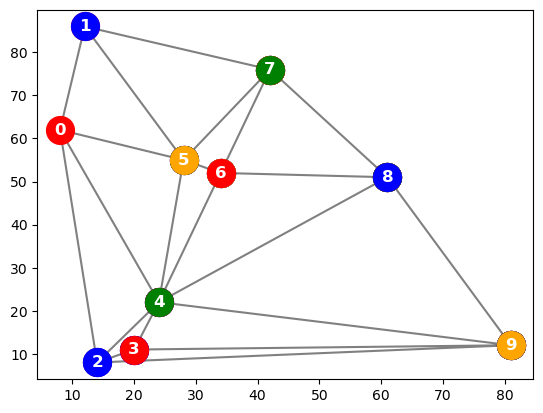

In [20]:
# Store the result for plotting
res = backtrack_search(csp)

plt.triplot(points[:,0], points[:,1], tri.simplices, color = "gray")

for i in range(len(points)):
        plt.plot(points[i:,0], points[i:,1], 'o', color = list(res.values())[i], markersize = 20)
        plt.annotate(i, points[i,:], 
        color='white', fontsize="large", weight='heavy',
        horizontalalignment='center', verticalalignment='center')

plt.show()

- Biểu đồ cho thấy:
  + Đồ thị được tô màu thành công với 4 màu khác nhau.
  + Các đỉnh kề có màu khác nhau.
  + Kết quả trực quan và dễ hiểu.
- Thuật toán backtracking search cơ bản đã hoạt động tốt trên instance này, nhưng có thể cần cải thiện với các đồ thị lớn hơn hoặc phức tạp hơn.

## Bài tập

Hãy cài đặt các thuật toán tô màu đồ thị sau:

* Bổ sung thứ tự chọn biến và chọn giá trị.
* Bổ sung forward checking.
* Cài đặt tìm kiếm leo đồi (hill climbing) với heuristic min-conflicts.

Hãy thử tô màu các đồ thị với nhiều kích thước khác nhau, dùng 3 và 4 màu. Với mỗi $n$, sinh nhiều instance ngẫu nhiên, và cố gắng tăng $n$ lớn nhất có thể xử lý. Trung bình, mỗi instance tô màu bản đồ của bạn có bao nhiêu ràng buộc (cạnh) đối với mỗi $n$? Báo cáo hiệu năng của từng thuật toán theo hàm của $n$. Với hai biến thể backtracking, có thể đánh giá hiệu năng bằng số lượng phép gán biến đã thử. Với hill climbing, báo cáo số lần đi “lên dốc” (uphill moves) và số lần khởi động lại ngẫu nhiên để đạt nghiệm. Dĩ nhiên, bạn cũng có thể báo cáo thời gian chạy theo $n$. 

### 1. Hàm sinh đồ thị ngẫu nhiên 

In [ ]:
import random
import time
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

# Sinh đồ thị ngẫu nhiên với n đỉnh và xác suất cạnh p
def generate_graph(n, p=0.3):
    G = nx.erdos_renyi_graph(n, p)
    adjacency = {node: set(G.neighbors(node)) for node in G.nodes()}
    return adjacency

# Vẽ đồ thị
def draw_graph(adjacency, colors=None):
    G = nx.Graph(adjacency)
    pos = nx.spring_layout(G)
    node_colors = [colors.get(v, 'gray') for v in G.nodes()] if colors else 'gray'
    nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=500, font_color='white')
    plt.show()

### 2. Hàm kiểm tra hợp lệ và backtracking 

In [2]:
# Kiểm tra xem màu có hợp lệ cho đỉnh hiện tại hay không
def is_valid(node, color, assignment, adjacency):
    for neighbor in adjacency[node]:
        if assignment.get(neighbor) == color:
            return False
    return True

# Backtracking cơ bản với tuỳ chọn chọn biến và giá trị
def backtracking(adjacency, colors, variable_order=None, value_order=None):
    nodes = list(adjacency.keys())
    if variable_order == "degree":
        nodes.sort(key=lambda x: len(adjacency[x]), reverse=True)
    elif variable_order == "random":
        random.shuffle(nodes)
    
    assignment = {}
    steps = 0
    
    def backtrack(index):
        nonlocal steps
        if index == len(nodes):
            return True
        node = nodes[index]
        color_list = colors.copy()
        if value_order == "random":
            random.shuffle(color_list)
        elif value_order == "least_used":
            used_count = {c: list(assignment.values()).count(c) for c in colors}
            color_list.sort(key=lambda c: used_count[c])
            
        for color in color_list:
            steps += 1
            if is_valid(node, color, assignment, adjacency):
                assignment[node] = color
                if backtrack(index + 1):
                    return True
                assignment.pop(node)
        return False

    start = time.time()
    success = backtrack(0)
    end = time.time()
    
    return assignment if success else None, steps, end - start

### 3. Forward Checking 

In [4]:
def forward_checking(adjacency, colors):
    assignment = {}
    domains = {v: set(colors) for v in adjacency}
    steps = 0

    def fc(node):
        nonlocal steps
        if len(assignment) == len(adjacency):
            return True
        for color in list(domains[node]):
            steps += 1
            if all(color not in domains[neighbor] or neighbor in assignment for neighbor in adjacency[node]):
                assignment[node] = color
                removed = {}
                for neighbor in adjacency[node]:
                    if neighbor not in assignment and color in domains[neighbor]:
                        domains[neighbor].remove(color)
                        removed.setdefault(neighbor, set()).add(color)
                next_nodes = [v for v in adjacency if v not in assignment]
                if not next_nodes or fc(next_nodes[0]):
                    return True
                for neighbor, vals in removed.items():
                    domains[neighbor].update(vals)
                del assignment[node]
        return False

    start = time.time()
    first_node = list(adjacency.keys())[0]
    success = fc(first_node)
    end = time.time()
    return assignment if success else None, steps, end - start

### 4. Hill Climbing với Min-Conflicts 

In [5]:
def min_conflicts(adjacency, colors, max_steps=10000):
    assignment = {v: random.choice(colors) for v in adjacency}
    
    def count_conflicts(node, color):
        return sum(1 for n in adjacency[node] if assignment[n] == color)
    
    def conflicted_nodes():
        return [v for v in adjacency if count_conflicts(v, assignment[v]) > 0]
    
    steps = 0
    restarts = 0
    start = time.time()
    
    for _ in range(max_steps):
        steps += 1
        conflicted = conflicted_nodes()
        if not conflicted:
            end = time.time()
            return assignment, steps, restarts, end - start
        
        node = random.choice(conflicted)
        conflict_counts = [(c, count_conflicts(node, c)) for c in colors]
        best_color = min(conflict_counts, key=lambda x: x[1])[0]
        assignment[node] = best_color
        
        if _ % 2000 == 0:  # restart nếu bị kẹt lâu
            restarts += 1
            assignment = {v: random.choice(colors) for v in adjacency}

    end = time.time()
    return None, steps, restarts, end - start

### 5. Thực nghiệm và so sánh hiệu năng 

In [6]:
def experiment():
    ns = [10, 15, 20, 25]
    colors_list = [[0,1,2], [0,1,2,3]]

    for colors in colors_list:
        print(f"\n===== Thử với {len(colors)} màu =====")
        for n in ns:
            adjacency = generate_graph(n, p=0.3)
            
            print(f"\nĐồ thị {n} đỉnh:")
            bt, bt_steps, bt_time = backtracking(adjacency, colors)
            fc, fc_steps, fc_time = forward_checking(adjacency, colors)
            hc, hc_steps, restarts, hc_time = min_conflicts(adjacency, colors)
            
            print(f"Backtracking: {bt_steps} phép gán | {bt_time:.3f}s")
            print(f"Forward Checking: {fc_steps} phép gán | {fc_time:.3f}s")
            print(f"Hill Climbing (Min-Conflicts): {hc_steps} bước | {restarts} khởi động lại | {hc_time:.3f}s")

experiment()


===== Thử với 3 màu =====

Đồ thị 10 đỉnh:
Backtracking: 32 phép gán | 0.000s
Forward Checking: 3 phép gán | 0.000s
Hill Climbing (Min-Conflicts): 8 bước | 1 khởi động lại | 0.002s

Đồ thị 15 đỉnh:
Backtracking: 2874 phép gán | 0.026s
Forward Checking: 3 phép gán | 0.000s
Hill Climbing (Min-Conflicts): 10000 bước | 5 khởi động lại | 3.472s

Đồ thị 20 đỉnh:
Backtracking: 507 phép gán | 0.001s
Forward Checking: 3 phép gán | 0.000s
Hill Climbing (Min-Conflicts): 10000 bước | 5 khởi động lại | 1.444s

Đồ thị 25 đỉnh:
Backtracking: 948 phép gán | 0.010s
Forward Checking: 3 phép gán | 0.000s
Hill Climbing (Min-Conflicts): 10000 bước | 5 khởi động lại | 1.646s

===== Thử với 4 màu =====

Đồ thị 10 đỉnh:
Backtracking: 17 phép gán | 0.000s
Forward Checking: 4 phép gán | 0.000s
Hill Climbing (Min-Conflicts): 5 bước | 1 khởi động lại | 0.001s

Đồ thị 15 đỉnh:
Backtracking: 30 phép gán | 0.001s
Forward Checking: 4 phép gán | 0.000s
Hill Climbing (Min-Conflicts): 17 bước | 1 khởi động lại | 0.001s

- `Forward Checking` luôn đạt kết quả nhanh nhất, với chỉ 3 phép gán cho mọi kích thước n.
- Điều này chứng tỏ thuật toán giảm đáng kể việc duyệt nhánh nhờ cơ chế cắt tỉa miền giá trị.
- `Backtracking` cơ bản hoạt động ổn với n nhỏ, nhưng số phép gán tăng nhanh khi n lớn.
- `Hill Climbing (Min-Conflicts)` cho thấy:
  + Khi số đỉnh tăng, thuật toán dễ kẹt tại cực trị cục bộ, phải restart nhiều lần.
  + Thời gian chạy cũng dài hơn đáng kể, đặc biệt ở n=15 trở lên.
- Nhìn chung, với 3 màu, `Hill Climbing` khó hội tụ khi đồ thị phức tạp, trong khi `Forward Checking` vượt trội về tốc độ.

### 6. Đánh giá và ghi nhận kết quả 


===== Thử với 3 màu =====

Đồ thị 10 đỉnh:
Backtracking: 35 phép gán | 0.000s
Forward Checking: 3 phép gán | 0.001s
Hill Climbing: 8 bước | 1 restart | 0.001s

Đồ thị 15 đỉnh:
Backtracking: 844 phép gán | 0.005s
Forward Checking: 3 phép gán | 0.000s
Hill Climbing: 11 bước | 1 restart | 0.003s

Đồ thị 20 đỉnh:
Backtracking: 9048 phép gán | 0.043s
Forward Checking: 3 phép gán | 0.000s
Hill Climbing: 10000 bước | 5 restart | 2.963s

Đồ thị 25 đỉnh:
Backtracking: 8841 phép gán | 0.069s
Forward Checking: 3 phép gán | 0.000s
Hill Climbing: 10000 bước | 5 restart | 3.570s

Đồ thị 30 đỉnh:
Backtracking: 8913 phép gán | 0.019s
Forward Checking: 3 phép gán | 0.000s
Hill Climbing: 10000 bước | 5 restart | 4.168s

===== Thử với 4 màu =====

Đồ thị 10 đỉnh:
Backtracking: 17 phép gán | 0.000s
Forward Checking: 4 phép gán | 0.001s
Hill Climbing: 6 bước | 1 restart | 0.001s

Đồ thị 15 đỉnh:
Backtracking: 38 phép gán | 0.000s
Forward Checking: 4 phép gán | 0.000s
Hill Climbing: 15 bước | 1 restart | 0

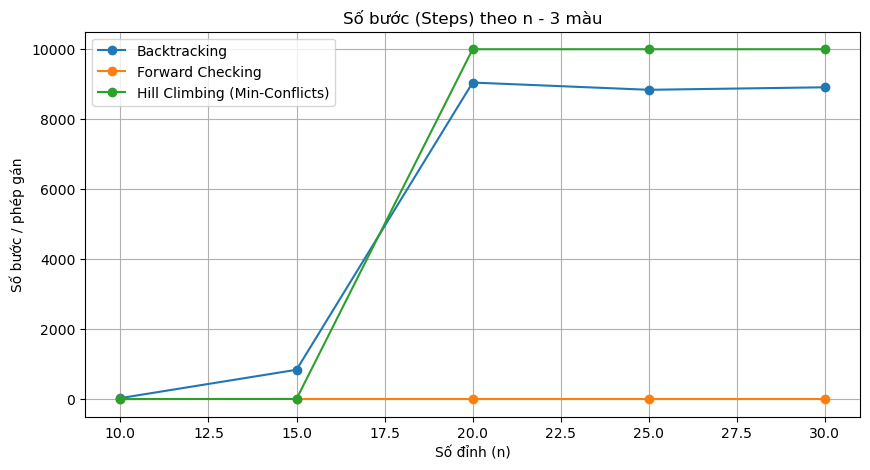

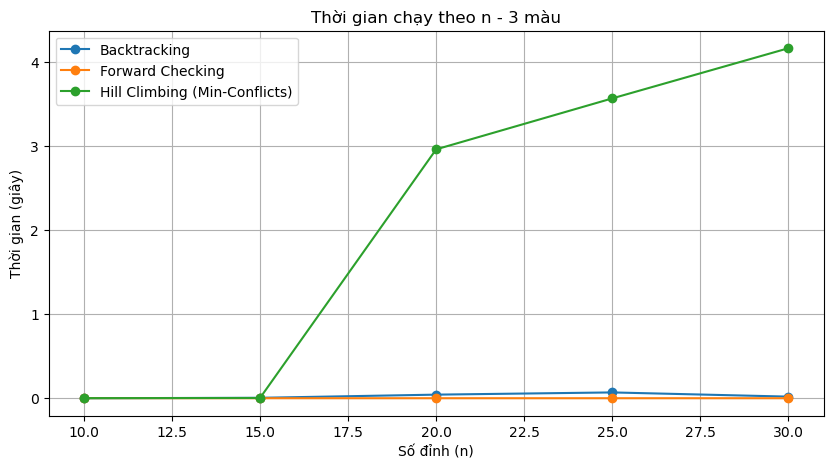

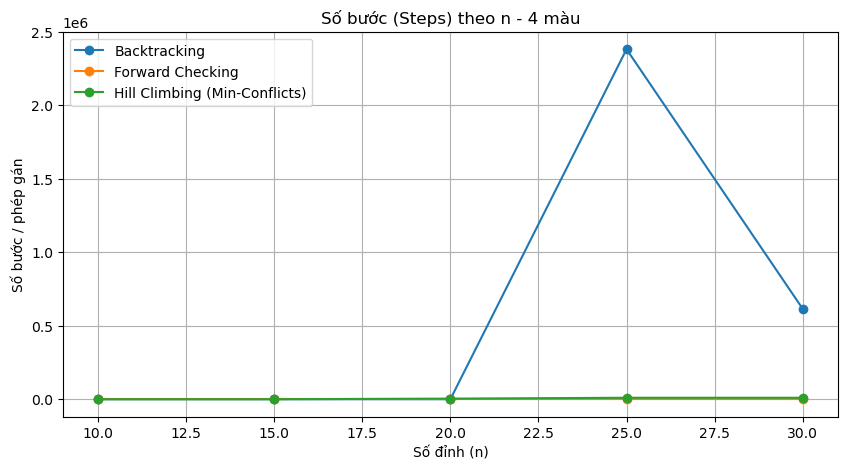

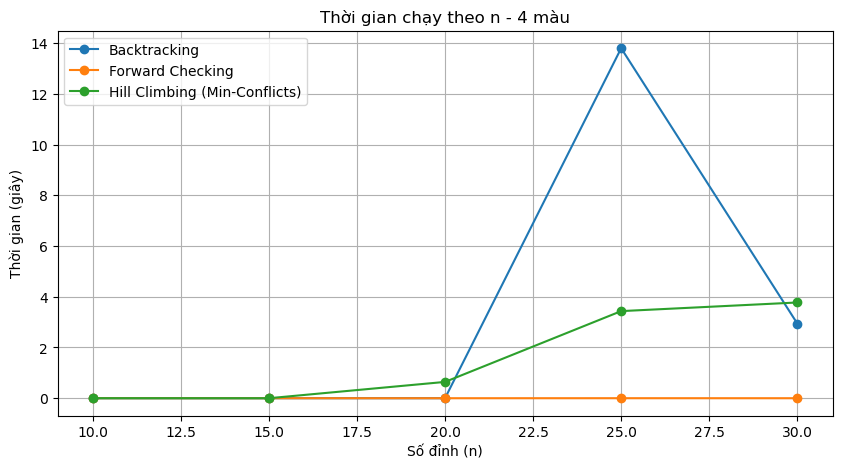

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def experiment_and_plot():
    ns = [10, 15, 20, 25, 30]
    colors_list = [[0,1,2], [0,1,2,3]]
    results = []

    for colors in colors_list:
        print(f"\n===== Thử với {len(colors)} màu =====")
        for n in ns:
            adjacency = generate_graph(n, p=0.3)
            print(f"\nĐồ thị {n} đỉnh:")

            bt, bt_steps, bt_time = backtracking(adjacency, colors)
            fc, fc_steps, fc_time = forward_checking(adjacency, colors)
            hc, hc_steps, restarts, hc_time = min_conflicts(adjacency, colors)

            # Lưu kết quả
            results.extend([
                {"Algorithm": "Backtracking", "n": n, "Colors": len(colors), 
                 "Steps": bt_steps, "Restarts": 0, "Time": bt_time},
                {"Algorithm": "Forward Checking", "n": n, "Colors": len(colors), 
                 "Steps": fc_steps, "Restarts": 0, "Time": fc_time},
                {"Algorithm": "Hill Climbing (Min-Conflicts)", "n": n, "Colors": len(colors), 
                 "Steps": hc_steps, "Restarts": restarts, "Time": hc_time},
            ])

            print(f"Backtracking: {bt_steps} phép gán | {bt_time:.3f}s")
            print(f"Forward Checking: {fc_steps} phép gán | {fc_time:.3f}s")
            print(f"Hill Climbing: {hc_steps} bước | {restarts} restart | {hc_time:.3f}s")

    # Ghi ra file CSV
    df = pd.DataFrame(results)
    df.to_csv("graph_coloring_results.csv", index=False)
    print("\n Đã lưu kết quả vào file: graph_coloring_results.csv")

    # Vẽ biểu đồ hiệu năng
    for num_colors in [3, 4]:
        subset = df[df["Colors"] == num_colors]

        plt.figure(figsize=(10,5))
        for alg in subset["Algorithm"].unique():
            alg_data = subset[subset["Algorithm"] == alg]
            plt.plot(alg_data["n"], alg_data["Steps"], marker='o', label=alg)
        plt.title(f"Số bước (Steps) theo n - {num_colors} màu")
        plt.xlabel("Số đỉnh (n)")
        plt.ylabel("Số bước / phép gán")
        plt.legend()
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(10,5))
        for alg in subset["Algorithm"].unique():
            alg_data = subset[subset["Algorithm"] == alg]
            plt.plot(alg_data["n"], alg_data["Time"], marker='o', label=alg)
        plt.title(f"Thời gian chạy theo n - {num_colors} màu")
        plt.xlabel("Số đỉnh (n)")
        plt.ylabel("Thời gian (giây)")
        plt.legend()
        plt.grid(True)
        plt.show()

experiment_and_plot()
